# LangGraph RAG Eval with RAGAS: Naive vs Semantic chunking

Lets setup API Keys:

In [50]:
import os
from getpass import getpass
os.environ["OPENAI_API_KEY"] = getpass("Please enter your OpenAI API key!")

Dataset generation using RAGAS

In [51]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from ragas.testset import TestsetGenerator
import copy
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader) 
docs = loader.load()

generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs[:30], testset_size=30)

dataset.to_pandas()

# For pandas DataFrames naive chunking
dataset_copy_naive = copy.deepcopy(dataset)
# For pandas DataFrames semantic chunking
dataset_copy_semantic = copy.deepcopy(dataset)


Applying HeadlinesExtractor:   0%|          | 0/26 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/30 [00:00<?, ?it/s]

unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node


Applying SummaryExtractor:   0%|          | 0/41 [00:00<?, ?it/s]

Property 'summary' already exists in node '538ded'. Skipping!
Property 'summary' already exists in node '86b291'. Skipping!
Property 'summary' already exists in node '812e10'. Skipping!
Property 'summary' already exists in node '4b3def'. Skipping!
Property 'summary' already exists in node 'e1dadc'. Skipping!
Property 'summary' already exists in node '46781a'. Skipping!
Property 'summary' already exists in node '297749'. Skipping!
Property 'summary' already exists in node 'fb0efb'. Skipping!
Property 'summary' already exists in node '05da6e'. Skipping!
Property 'summary' already exists in node '86bd0f'. Skipping!
Property 'summary' already exists in node '60fcaa'. Skipping!
Property 'summary' already exists in node '22f7c9'. Skipping!
Property 'summary' already exists in node 'e58a84'. Skipping!
Property 'summary' already exists in node '3c69e3'. Skipping!
Property 'summary' already exists in node 'aaf318'. Skipping!


...

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Task exception was never retrieved
future: <Task finished name='Task-3933' coro=<as_completed.<locals>.sema_coro() done, defined at /home/jsmejia/the_ai_eng_bootcamp/code/AIE7/08_Evaluating_RAG_With_Ragas/.venv/lib/python3.13/site-packages/ragas/executor.py:46> exception=RateLimitError("Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4.1 in organization org-cwzpGuyE6Nj7z8oNjwDjnjOy on tokens per min (TPM): Limit 30000, Used 30000, Requested 1390. Please try again in 2.78s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}")>
Traceback (most recent call last):
  File "/home/jsmejia/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/asyncio/tasks.py", line 304, in __step_run_and_handle_result
    result = coro.send(None)
  File "/home/jsmejia/the_ai_eng_bootcamp/code/AIE7/08_Evaluating_RAG_With_Ragas/.venv/lib/python3.13/site-packages/ragas/executor.py", line 48, i

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/30 [00:00<?, ?it/s]

LangGraph\LangChain RAG. Definition of vector stores:

In [52]:

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader
import os, glob
from semantic_chunk_tool import extract_and_chunk_paragraphs

path = "data/"

# Naive Chunking:
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
split_documents = text_splitter.split_documents(docs)

# Semantic Chunking:
pdf_pattern = os.path.join(path, "*.pdf")
pdf_files = glob.glob(pdf_pattern)
    
if not pdf_files:
  print(f"No PDF files found in {path}")
    
split_documents_semantic =[]

for pdf_file in pdf_files:
  split_documents_semantic.extend(extract_and_chunk_paragraphs(pdf_file))

# define embeddings
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# define qdrant client
client = QdrantClient(":memory:")

# define collections:
client.create_collection(
    collection_name="loan_data_naive",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
client.create_collection(
    collection_name="loan_data_semantic",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

# define vector stores:
vector_store_naive = QdrantVectorStore(
    client=client,
    collection_name="loan_data_naive",
    embedding=embeddings,
)
vector_store_semantic = QdrantVectorStore(
    client=client,
    collection_name="loan_data_semantic",
    embedding=embeddings,
)

# add documents to vector stores:
_ = vector_store_naive.add_documents(documents=split_documents)
retriever_naive = vector_store_naive .as_retriever(search_kwargs={"k": 5})

_ = vector_store_semantic.add_documents(documents=split_documents)
retriever_semantic = vector_store_semantic .as_retriever(search_kwargs={"k": 5})

Definition of RAG graphs:

In [53]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langchain.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

#Define common elements:

class State(TypedDict):
  question: str
  context: List[Document]
  response: str

# Define prompt:
RAG_PROMPT = """\
You are a helpful assistant who answers questions based on provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

llm = ChatOpenAI(model="gpt-4.1-nano")

def generate(state):
  docs_content = "\n\n".join(doc.page_content for doc in state["context"])
  messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
  response = llm.invoke(messages)
  return {"response" : response.content}

# Define retrieve functions:
def retrieve_naive(state):
  retrieved_docs = retriever_naive.invoke(state["question"])
  return {"context" : retrieved_docs}

def retrieve_semantic(state):
  retrieved_docs = retriever_semantic.invoke(state["question"])
  return {"context" : retrieved_docs}

# Define graph builder for naive chunking:
graph_builder_naive = StateGraph(State).add_sequence([retrieve_naive, generate])
graph_builder_naive.add_edge(START, "retrieve_naive")
graph_naive = graph_builder_naive.compile()

response_naive = graph_naive .invoke({"question" : "What are the different kinds of loans?"})

response_naive["response"]

# Define graph builder for naive chunking:
graph_builder_semantic = StateGraph(State).add_sequence([retrieve_semantic, generate])
graph_builder_semantic.add_edge(START, "retrieve_semantic")
graph_semantic = graph_builder_semantic.compile()

response_semantic = graph_semantic .invoke({"question" : "What are the different kinds of loans?"})

response_semantic["response"]

"The context mentions several types of loans, including:\n\n1. **Direct Subsidized Loan**\n2. **Direct Unsubsidized Loan**\n3. **Federal PLUS Loans (including Direct PLUS Loans and Federal PLUS Loans)**\n4. **Subsidized Federal Stafford Loan**\n5. **Unsubsidized Federal Stafford Loan**\n6. **Federal Supplemental Loans for Students (SLS)**\n7. **Private loans**\n8. **State-sponsored loans**\n9. **Institutional loans**\n10. **Student loan originator's income share agreement (ISA)**\n\nThese are the various kinds of loans referenced in the provided information."

Generate datasets (fill in the gaps) based on RAG answers:

In [54]:
# Naive Chunking dataset:
for test_row in dataset_copy_naive:
  response = graph_naive.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

dataset_copy_naive.samples[0].eval_sample.response

# Semantic Chunking dataset:
for test_row in dataset_copy_semantic:
  response = graph_semantic.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

dataset_copy_semantic.samples[0].eval_sample.response

'You can find more information about DCL GEN-11-07 and its rules for Direct PLUS Loans by referring to the official Department of Education documents and notices. Specifically, the Department of Education\'s Electronic Announcements, such as the one dated October 18, 2016, titled "Direct PLUS Loan Application NSLDS Default Check," contain relevant guidance and updates. Additionally, the regulations and definitions related to adverse credit history and default, such as 34 CFR 685.200(c)(2)(viii)(B), 34 CFR 685.200(b)(5), and 34 CFR 685.211(e), provide the regulatory framework.\n\nFor comprehensive details, visit the StudentAid.gov website and review the Department\'s official publications and announcements, which include the Direct PLUS Loan application procedures, default checks, and related rules. These sources will give you authoritative guidance on the rules and policies associated with DCL GEN-11-07 and Direct PLUS Loans.'

RAGAS evaluation dataset definitions:

In [55]:
from ragas import EvaluationDataset
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper

evaluation_dataset_naive = EvaluationDataset.from_pandas(dataset_copy_naive.to_pandas())
evaluation_dataset_semantic = EvaluationDataset.from_pandas(dataset_copy_semantic.to_pandas())

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))

Desired metrics:

- Faithfulness  
- Answer Relevancy  
- Context Precision  
- Context Recall  
- Answer Correctness  

In [56]:
from ragas.metrics import Faithfulness, ResponseRelevancy, LLMContextPrecisionWithReference, LLMContextRecall, FactualCorrectness
from ragas import evaluate, RunConfig

custom_run_config = RunConfig(timeout=360)

result_naive = evaluate( #type: ignore
    dataset=evaluation_dataset_naive,
    metrics=[Faithfulness(), ResponseRelevancy(), LLMContextPrecisionWithReference(), LLMContextRecall(), FactualCorrectness()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
result_naive

result_semantic = evaluate( #type: ignore
    dataset=evaluation_dataset_semantic,
    metrics=[Faithfulness(), ResponseRelevancy(), LLMContextPrecisionWithReference(), LLMContextRecall(), FactualCorrectness()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
result_semantic

Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

Exception raised in Job[0]: AttributeError('StringIO' object has no attribute 'statements')


{'faithfulness': 0.8846, 'answer_relevancy': 0.9071, 'llm_context_precision_with_reference': 0.9309, 'context_recall': 0.8741, 'factual_correctness': 0.5610}

In [57]:
result_naive

{'faithfulness': 0.8734, 'answer_relevancy': 0.9119, 'llm_context_precision_with_reference': 0.9429, 'context_recall': 0.8805, 'factual_correctness': 0.5937}

In [58]:
result_semantic

{'faithfulness': 0.8846, 'answer_relevancy': 0.9071, 'llm_context_precision_with_reference': 0.9309, 'context_recall': 0.8741, 'factual_correctness': 0.5610}

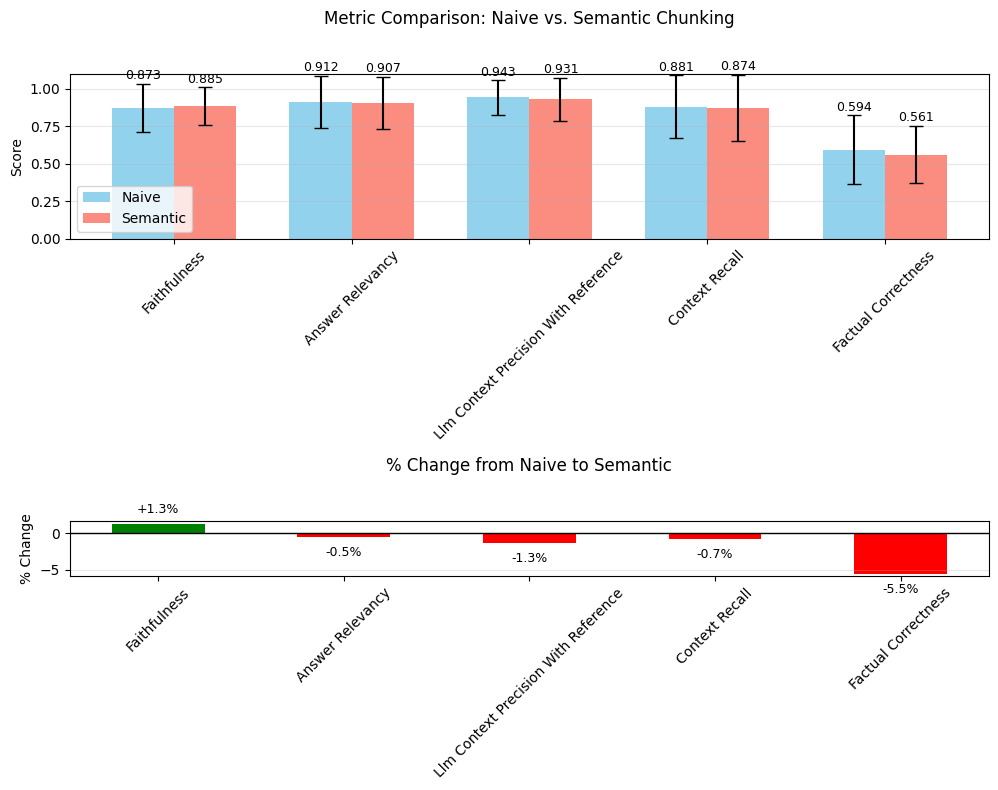

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Convert to DataFrames
df_naive = result_naive.to_pandas()
df_semantic = result_semantic.to_pandas()

# Compute means and standard deviations
naive_means = df_naive.mean(numeric_only=True)
naive_stds = df_naive.std(numeric_only=True)

semantic_means = df_semantic.mean(numeric_only=True)
semantic_stds = df_semantic.std(numeric_only=True)

# Extract metrics and values
metrics = list(naive_means.keys())
naive_scores = [naive_means[m] for m in metrics]
semantic_scores = [semantic_means[m] for m in metrics]
naive_err = [naive_stds[m] for m in metrics]
semantic_err = [semantic_stds[m] for m in metrics]
percent_change = [((s - n) / n) * 100 for s, n in zip(semantic_scores, naive_scores)]

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

x = np.arange(len(metrics))
width = 0.35

# Bar chart with error bars
bars1 = ax1.bar(x - width/2, naive_scores, width, yerr=naive_err, capsize=5, label='Naive', color='skyblue', alpha=0.9)
bars2 = ax1.bar(x + width/2, semantic_scores, width, yerr=semantic_err, capsize=5, label='Semantic', color='salmon', alpha=0.9)

ax1.set_ylabel('Score')
ax1.set_title('Metric Comparison: Naive vs. Semantic Chunking\n\n')
ax1.set_xticks(x)
ax1.set_xticklabels([m.replace('_', ' ').title() for m in metrics], rotation=45)
ax1.legend()
ax1.set_ylim(0, 1.1)
ax1.grid(True, axis='y', alpha=0.3)

# Add value labels above bars
for i in range(len(metrics)):
    ax1.text(x[i] - width/2, naive_scores[i] + naive_err[i] + 0.01, f'{naive_scores[i]:.3f}', ha='center', va='bottom', fontsize=9)
    ax1.text(x[i] + width/2, semantic_scores[i] + semantic_err[i] + 0.01, f'{semantic_scores[i]:.3f}', ha='center', va='bottom', fontsize=9)

# % change bar chart
colors = ['green' if p >= 0 else 'red' for p in percent_change]
ax2.bar(x, percent_change, width=0.5, color=colors)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_ylabel('% Change')
ax2.set_xticks(x)
ax2.set_xticklabels([m.replace('_', ' ').title() for m in metrics], rotation=45)
ax2.set_title('% Change from Naive to Semantic\n\n')
ax2.grid(True, axis='y', alpha=0.3)

# Add % labels
for i, pct in enumerate(percent_change):
    ax2.text(x[i], pct + (1 if pct >= 0 else -3), f'{pct:+.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
